# CC combined scenarios - discharge analysis August 2026


In [1]:
# Install required packages
import pandas as pd
from pathlib import Path
import os                      
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [2]:
# Discharge outputs

# Baseline LC scenarios (no cc)
baseline = pd.read_csv("../Data/LULC/Eddleston_LC_baselineDetailedTS_M11.txt", sep="\\t")
baseline["Time"] = pd.to_datetime(baseline["Time"])
baseline = baseline.set_index("Time")

a2 = pd.read_csv("../Data/LULC/Eddleston_LC_A2DetailedTS_M11.txt", sep="\\t")
a2["Time"] = pd.to_datetime(a2["Time"])
a2 = a2.set_index("Time")

c = pd.read_csv("../Data/LULC/Eddleston_LC_CDetailedTS_M11.txt", sep="\\t")
c["Time"] = pd.to_datetime(c["Time"])
c = c.set_index("Time")


# Just climate change (baseline LC)
og_2050_45 = pd.read_csv("../Data/CCcombined/Eddleston_baseline_2050_45_50DetailedTS_M11.txt", sep="\\t")
og_2050_45["Time"] = pd.to_datetime(og_2050_45["Time"])
og_2050_45 = og_2050_45.set_index("Time")

og_2050_85 = pd.read_csv("../Data/CCcombined/Eddleston_baseline_2050_85_50DetailedTS_M11.txt", sep="\\t")
og_2050_85["Time"] = pd.to_datetime(og_2050_85["Time"])
og_2050_85 = og_2050_85.set_index("Time")

og_2080_45 = pd.read_csv("../Data/CCcombined/Eddleston_baseline_2080_45_50DetailedTS_M11.txt", sep="\\t")
og_2080_45["Time"] = pd.to_datetime(og_2080_45["Time"])
og_2080_45 = og_2080_45.set_index("Time")

og_2080_85 = pd.read_csv("../Data/CCcombined/Eddleston_baseline_2080_85_50DetailedTS_M11.txt", sep="\\t")
og_2080_85["Time"] = pd.to_datetime(og_2080_85["Time"])
og_2080_85 = og_2080_85.set_index("Time")


# Combined cc and a2 scenario
a2_2050_45 = pd.read_csv("../Data/CCcombined/Eddleston_A2_2050_45_50DetailedTS_M11.txt", sep="\\t")
a2_2050_45["Time"] = pd.to_datetime(a2_2050_45["Time"])
a2_2050_45 = a2_2050_45.set_index("Time")

a2_2050_85 = pd.read_csv("../Data/CCcombined/Eddleston_A2_2050_85_50DetailedTS_M11.txt", sep="\\t")
a2_2050_85["Time"] = pd.to_datetime(a2_2050_85["Time"])
a2_2050_85 = a2_2050_85.set_index("Time")

a2_2080_45 = pd.read_csv("../Data/CCcombined/Eddleston_A2_2080_45_50DetailedTS_M11.txt", sep="\\t")
a2_2080_45["Time"] = pd.to_datetime(a2_2080_45["Time"])
a2_2080_45 = a2_2080_45.set_index("Time")

a2_2080_85 = pd.read_csv("../Data/CCcombined/Eddleston_A2_2080_85_50DetailedTS_M11.txt", sep="\\t")
a2_2080_85["Time"] = pd.to_datetime(a2_2080_85["Time"])
a2_2080_85 = a2_2080_85.set_index("Time")


# Combined cc and c scenario
c_2050_45 = pd.read_csv("../Data/CCcombined/Eddleston_C_2050_45_50DetailedTS_M11.txt", sep="\\t")
c_2050_45["Time"] = pd.to_datetime(c_2050_45["Time"])
c_2050_45 = c_2050_45.set_index("Time")

c_2050_85 = pd.read_csv("../Data/CCcombined/Eddleston_C_2050_85_50DetailedTS_M11.txt", sep="\\t")
c_2050_85["Time"] = pd.to_datetime(c_2050_85["Time"])
c_2050_85 = c_2050_85.set_index("Time")

c_2080_45 = pd.read_csv("../Data/CCcombined/Eddleston_C_2080_45_50DetailedTS_M11.txt", sep="\\t")
c_2080_45["Time"] = pd.to_datetime(c_2080_45["Time"])
c_2080_45 = c_2080_45.set_index("Time")

c_2080_85 = pd.read_csv("../Data/CCcombined/Eddleston_C_2080_85_50DetailedTS_M11.txt", sep="\\t")
c_2080_85["Time"] = pd.to_datetime(c_2080_85["Time"])
c_2080_85 = c_2080_85.set_index("Time")


/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_56052/3099374505.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  baseline = pd.read_csv("../Data/LULC/Eddleston_LC_baselineDetailedTS_M11.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_56052/3099374505.py:8: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  a2 = pd.read_csv("../Data/LULC/Eddleston_LC_A2DetailedTS_M11.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_56052/3099374505.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separa

In [3]:
# Annual mean flows

# 2050s

scenario_data = {
    "Baseline": baseline,
    "RCP4.5 2050": og_2050_45,
    "RCP8.5 2050": og_2050_85,
    "RCP4.5 2080": og_2080_45,
    "RCP8.5 2080": og_2080_85,
}

start_date = "2011-03-23"
end_date = "2020-03-05"

annual_means = {}

for scenario, df in scenario_data.items():
    selected = df.loc[start_date:end_date]

    numeric_cols = selected.select_dtypes(include="number").columns

    annual_means[scenario] = (
        selected[numeric_cols]
        .resample("YE")
        .mean()
    )

# Combine into one table
annual_mean_table = pd.concat(
    annual_means,
    names=["scenario", "year"]
).reset_index()

annual_summary = pd.DataFrame({
    "Baseline": annual_means["Baseline"].mean(),
    "RCP4.5 2050": annual_means["RCP4.5 2050"].mean(),
    "RCP8.5 2050": annual_means["RCP8.5 2050"].mean(),
    "RCP4.5 2080": annual_means["RCP4.5 2080"].mean(),
    "RCP8.5 2080": annual_means["RCP8.5 2080"].mean(),
})

annual_summary["RCP4.5_2050_change_%"] = (
    (annual_summary["RCP4.5 2050"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP8.5_2050_change_%"] = (
    (annual_summary["RCP8.5 2050"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP4.5_2080_change_%"] = (
    (annual_summary["RCP4.5 2080"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP8.5_2080_change_%"] = (
    (annual_summary["RCP8.5 2080"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

print(annual_summary)

                 Baseline  RCP4.5 2050  RCP8.5 2050  RCP4.5 2080  RCP8.5 2080  \
Shiplaw_Burn     0.052334     0.053791     0.053540     0.052333     0.052509   
Middle_Burn      0.033211     0.033847     0.033659     0.032843     0.032784   
Middle_Longcote  0.062399     0.064401     0.064370     0.063828     0.064532   
Kidston_Mill     0.860606     0.889324     0.887842     0.871933     0.878713   

                 RCP4.5_2050_change_%  RCP8.5_2050_change_%  \
Shiplaw_Burn                 2.783967              2.304524   
Middle_Burn                  1.914115              1.350201   
Middle_Longcote              3.207549              3.158089   
Kidston_Mill                 3.336948              3.164819   

                 RCP4.5_2080_change_%  RCP8.5_2080_change_%  
Shiplaw_Burn                -0.001965              0.333868  
Middle_Burn                 -1.106430             -1.285049  
Middle_Longcote              2.290357              3.417223  
Kidston_Mill                 1

In [4]:
# same for 2080s 

scenario_data = {
    "Baseline": baseline,
    "RCP4.5 2080 A2": a2_2080_45,
    "RCP4.5 2080 C": c_2080_45,
    "RCP8.5 2080 A2": a2_2080_85,
    "RCP8.5 2080 C": c_2080_85,
}

start_date = "2011-03-23"
end_date = "2020-03-05"

annual_means = {}

for scenario, df in scenario_data.items():
    selected = df.loc[start_date:end_date]

    numeric_cols = selected.select_dtypes(include="number").columns

    annual_means[scenario] = (
        selected[numeric_cols]
        .resample("YE")
        .mean()
    )

# Combine into one table
annual_mean_table = pd.concat(
    annual_means,
    names=["scenario", "year"]
).reset_index()

annual_summary = pd.DataFrame({
    "Baseline": annual_means["Baseline"].mean(),
    "RCP4.5 2080 A2": annual_means["RCP4.5 2080 A2"].mean(),
    "RCP4.5 2080 C": annual_means["RCP4.5 2080 C"].mean(),
    "RCP8.5 2080 A2": annual_means["RCP8.5 2080 A2"].mean(),
    "RCP8.5 2080 C": annual_means["RCP8.5 2080 C"].mean(),
})

annual_summary["RCP4.5_2080_A2_change_%"] = (
    (annual_summary["RCP4.5 2080 A2"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP4.5_2080_C_change_%"] = (
    (annual_summary["RCP4.5 2080 C"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP8.5_2080_A2_change_%"] = (
    (annual_summary["RCP8.5 2080 A2"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

annual_summary["RCP8.5_2080_C_change_%"] = (
    (annual_summary["RCP8.5 2080 C"] - annual_summary["Baseline"])
    / annual_summary["Baseline"] * 100
)

print(annual_summary)

                 Baseline  RCP4.5 2080 A2  RCP4.5 2080 C  RCP8.5 2080 A2  \
Shiplaw_Burn     0.052334        0.046662       0.050444        0.046330   
Middle_Burn      0.033211        0.024442       0.032848        0.023796   
Middle_Longcote  0.062399        0.063784       0.063688        0.064480   
Kidston_Mill     0.860606        0.833885       0.852887        0.837718   

                 RCP8.5 2080 C  RCP4.5_2080_A2_change_%  \
Shiplaw_Burn          0.050531               -10.837366   
Middle_Burn           0.032794               -26.403903   
Middle_Longcote       0.064423                 2.219356   
Kidston_Mill          0.858766                -3.104889   

                 RCP4.5_2080_C_change_%  RCP8.5_2080_A2_change_%  \
Shiplaw_Burn                  -3.611674               -11.472592   
Middle_Burn                   -1.091562               -28.348938   
Middle_Longcote                2.064586                 3.333854   
Kidston_Mill                  -0.896926            

## Monthly regimes 

In [5]:
calendar_months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
start_date = "2011-03-23"
end_date = "2020-03-05"

def monthly_regime(df, gauge, start_date=None, end_date=None):
    df2 = df.copy()

    if not isinstance(df2.index, pd.DatetimeIndex):
        df2.index = pd.to_datetime(df2.index)

    if start_date is not None:
        df2 = df2.loc[df2.index >= pd.Timestamp(start_date)]

    if end_date is not None:
        df2 = df2.loc[df2.index <= pd.Timestamp(end_date)]

    s = (
        df2[gauge]
        .groupby(df2.index.month)
        .mean()
        .reindex(range(1, 13))
    )
    s.index = calendar_months
    return s

# Shiplaw Burn
SB_discharge_regimes = pd.DataFrame(index=calendar_months)

SB_discharge_regimes["baseline"] = monthly_regime(baseline, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["2050_45"] = monthly_regime(og_2050_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["2050_85"] = monthly_regime(og_2050_85, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["2080_45"] = monthly_regime(og_2080_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["2080_85"] = monthly_regime(og_2080_85, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["a2"] = monthly_regime(a2, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["a2_2050_45"] = monthly_regime(a2_2050_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["a2_2050_85"] = monthly_regime(a2_2050_85, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["a2_2080_45"] = monthly_regime(a2_2080_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["a2_2080_85"] = monthly_regime(a2_2080_85, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["c"] = monthly_regime(c, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["c_2050_45"] = monthly_regime(c_2050_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["c_2050_85"] = monthly_regime(c_2050_85, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["c_2080_45"] = monthly_regime(c_2080_45, "Shiplaw_Burn", start_date, end_date)
SB_discharge_regimes["c_2080_85"] = monthly_regime(c_2080_85, "Shiplaw_Burn", start_date, end_date)

# Kidston Mill
KM_discharge_regimes = pd.DataFrame(index=calendar_months)

KM_discharge_regimes["baseline"] = monthly_regime(baseline, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["2050_45"] = monthly_regime(og_2050_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["2050_85"] = monthly_regime(og_2050_85, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["2080_45"] = monthly_regime(og_2080_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["2080_85"] = monthly_regime(og_2080_85, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["a2"] = monthly_regime(a2, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["a2_2050_45"] = monthly_regime(a2_2050_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["a2_2050_85"] = monthly_regime(a2_2050_85, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["a2_2080_45"] = monthly_regime(a2_2080_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["a2_2080_85"] = monthly_regime(a2_2080_85, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["c"] = monthly_regime(c, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["c_2050_45"] = monthly_regime(c_2050_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["c_2050_85"] = monthly_regime(c_2050_85, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["c_2080_45"] = monthly_regime(c_2080_45, "Kidston_Mill", start_date, end_date)
KM_discharge_regimes["c_2080_85"] = monthly_regime(c_2080_85, "Kidston_Mill", start_date, end_date)

# Middle Longcote
ML_discharge_regimes = pd.DataFrame(index=calendar_months)

ML_discharge_regimes["baseline"] = monthly_regime(baseline, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["2050_45"] = monthly_regime(og_2050_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["2050_85"] = monthly_regime(og_2050_85, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["2080_45"] = monthly_regime(og_2080_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["2080_85"] = monthly_regime(og_2080_85, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["a2"] = monthly_regime(a2, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["a2_2050_45"] = monthly_regime(a2_2050_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["a2_2050_85"] = monthly_regime(a2_2050_85, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["a2_2080_45"] = monthly_regime(a2_2080_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["a2_2080_85"] = monthly_regime(a2_2080_85, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["c"] = monthly_regime(c, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["c_2050_45"] = monthly_regime(c_2050_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["c_2050_85"] = monthly_regime(c_2050_85, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["c_2080_45"] = monthly_regime(c_2080_45, "Middle_Longcote", start_date, end_date)
ML_discharge_regimes["c_2080_85"] = monthly_regime(c_2080_85, "Middle_Longcote", start_date, end_date)

In [6]:
# Re-order months to hydrological year (Sep-Aug)
hydro_months = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]

SB_discharge_regimes = (
    SB_discharge_regimes
    .reindex(calendar_months)
    .reindex(hydro_months)
)

KM_discharge_regimes = (
    KM_discharge_regimes
    .reindex(calendar_months)
    .reindex(hydro_months)
)

ML_discharge_regimes = (
    ML_discharge_regimes
    .reindex(calendar_months)
    .reindex(hydro_months)
)

In [7]:
# Seasonal statistics only for each LC scenario
scenarios = {
    "Baseline": baseline,
    "RCP4.5": og_2080_45,
    "RCP8.5": og_2080_85,
    "A2": a2,
    "C": c,
    "RCP4.5+A2": a2_2080_45,
    "RCP8.5+A2": a2_2080_85,
    "RCP4.5+C": c_2080_45,
    "RCP8.5+C": c_2080_85,
}

month_to_season = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}

def compute_summary(df):
    return pd.DataFrame({
        "mean": df.mean(),
        "p05": df.quantile(0.05),
        "p95": df.quantile(0.95),
    })

def compute_seasonal_summary(df):
    temp = df.copy()
    temp["season"] = temp.index.month.map(month_to_season)
    data_cols = [col for col in temp.columns if col != "season"]
    return (
        temp
        .groupby("season")
        .apply(lambda group: compute_summary(group[data_cols]))
        .rename_axis(index=["season", "subcatchment"])
        .reset_index()
    )

seasonal_results = []
for scenario_name, df in scenarios.items():
    seasonal = compute_seasonal_summary(df)
    seasonal["scenario"] = scenario_name
    seasonal_results.append(seasonal)

seasonal_stats_all = pd.concat(seasonal_results, ignore_index=True)
seasonal_stats_all = seasonal_stats_all[["scenario", "season", "subcatchment", "mean", "p05", "p95"]]
seasonal_stats_all[["mean", "p05", "p95"]] = seasonal_stats_all[["mean", "p05", "p95"]].round(5)

print("\nSeasonal statistics for all LC scenarios")
print(seasonal_stats_all.head(20))

output_path = Path("../Results/CC_seasonal_flow_stats_by_scenario.csv")
seasonal_stats_all.to_csv(output_path, index=False)
print(f"\nExported seasonal summary table to: {output_path}")



Seasonal statistics for all LC scenarios
    scenario season     subcatchment     mean      p05      p95
0   Baseline    DJF     Shiplaw_Burn  0.09719  0.01167  0.32127
1   Baseline    DJF      Middle_Burn  0.06046  0.00917  0.19708
2   Baseline    DJF  Middle_Longcote  0.09523  0.03081  0.22165
3   Baseline    DJF     Kidston_Mill  1.52995  0.20788  4.83931
4   Baseline    JJA     Shiplaw_Burn  0.01645  0.00430  0.04532
5   Baseline    JJA      Middle_Burn  0.01093  0.00344  0.03501
6   Baseline    JJA  Middle_Longcote  0.03256  0.00854  0.08061
7   Baseline    JJA     Kidston_Mill  0.28495  0.07342  1.00425
8   Baseline    MAM     Shiplaw_Burn  0.02817  0.00689  0.10426
9   Baseline    MAM      Middle_Burn  0.01781  0.00491  0.06002
10  Baseline    MAM  Middle_Longcote  0.04951  0.01666  0.09840
11  Baseline    MAM     Kidston_Mill  0.49296  0.10058  1.80928
12  Baseline    SON     Shiplaw_Burn  0.03374  0.00366  0.13964
13  Baseline    SON      Middle_Burn  0.02248  0.00324  0.0857

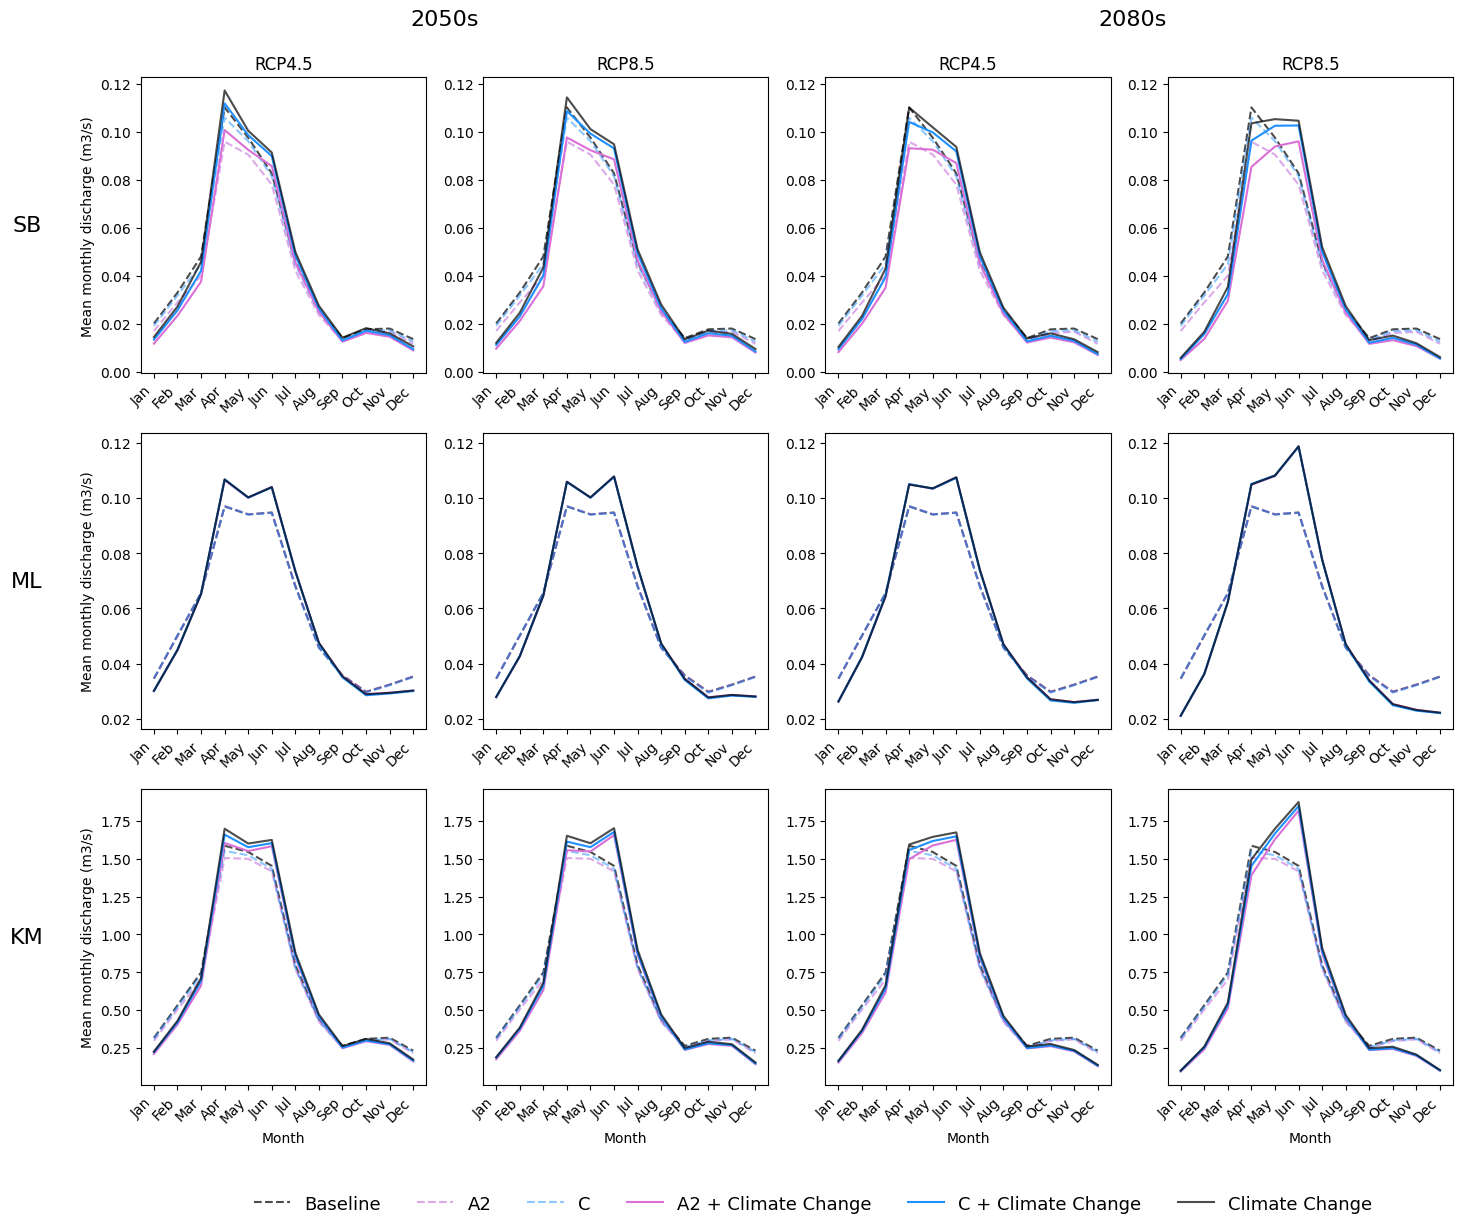

In [8]:
# Big climate change panel (2050s, 2080s, both RCPs)

rows = [("SB", SB_discharge_regimes), ("ML", ML_discharge_regimes), ("KM", KM_discharge_regimes)]

col_specs = [
    ('2050', '45', 'RCP4.5'),
    ('2050', '85', 'RCP8.5'),
    ('2080', '45', 'RCP4.5'),
    ('2080', '85', 'RCP8.5'),
]

def plot_if_exists(ax, df, key, label=None, **kw):
    if key in df.columns:
        ax.plot(df.index, df[key], label=(label or key), **kw)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = np.array(axes).reshape(3, 4)

for row_idx, (name, df) in enumerate(rows):
    for col_idx, (period_key, rcp, col_title) in enumerate(col_specs):
        ax = axes[row_idx, col_idx]

        # Create single legend entry for climate-only projections
        label_cc = 'Climate Change' if (period_key == '2050' and rcp == '45') else '_nolegend_'
        label_a2 = 'A2 + Climate Change' if (period_key == '2050' and rcp == '45') else '_nolegend_'
        label_c = 'C + Climate Change' if (period_key == '2050' and rcp == '45') else '_nolegend_'
        
        # Common lines (baseline + LC scenarios)
        plot_if_exists(ax, df, 'baseline', label='Baseline', linestyle='dashed', color='black', alpha=0.7)
        plot_if_exists(ax, df, 'a2', label='A2', linestyle='dashed', color='mediumorchid', alpha=0.5)
        plot_if_exists(ax, df, 'c', label='C', linestyle='dashed', color='dodgerblue', alpha=0.5)

        # Climate-only and combined LC + climate lines
        plot_if_exists(ax, df, f'a2_{period_key}_{rcp}', label=label_a2, color='orchid', alpha=1)
        plot_if_exists(ax, df, f'c_{period_key}_{rcp}', label=label_c, color='dodgerblue', alpha=1)
        plot_if_exists(ax, df, f'{period_key}_{rcp}', label=label_cc, color='black', alpha=0.7)
        
        if col_idx == 0:
            ax.set_ylabel(f"Mean monthly discharge (m3/s)")

        if row_idx == 0:
            ax.set_title(col_title)

        ax.set_xlabel("Month")
        if row_idx == len(rows) - 1:
            ax.set_xlabel("Month")
        else:
            ax.set_xlabel("")
        ax.set_xticks(range(len(calendar_months)))
        ax.set_xticklabels(calendar_months, rotation=45, ha="right")
        ax.tick_params(labelbottom=True)

for i in range(3):
    row_axes = axes[i, :]
    y_vals = np.hstack([
        line.get_ydata()
        for ax in row_axes
        for line in ax.get_lines()
    ]) if any(ax.get_lines() for ax in row_axes) else np.array([0.0])

    ymin = float(y_vals.min())
    ymax = float(y_vals.max())

    yrange = ymax - ymin
    pad = 0.05 * yrange if yrange > 0 else 0.1

    for ax in row_axes:
        ax.set_ylim(ymin - pad, ymax + pad)

for ax in axes.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.subplots_adjust(left=0.08)

# Sub-catchment names 
plt.draw()

for row_idx, (name, df) in enumerate(rows):
    axes[row_idx, 0].text(-0.4, 0.5, 
        name, transform=axes[row_idx, 0].transAxes,
        ha='center',
        va='center',
        fontsize=16)

handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(handles, labels, loc='lower center', ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.01), fontsize=13)

# Grouped column titles 
try:
    pos0 = axes[0, 0].get_position()
    pos1 = axes[0, 1].get_position()
    pos2 = axes[0, 2].get_position()
    pos3 = axes[0, 3].get_position()
    left0, right0 = min(pos0.x0, pos1.x0), max(pos0.x1, pos1.x1)
    left1, right1 = min(pos2.x0, pos3.x0), max(pos2.x1, pos3.x1)
    center0 = (left0 + right0) / 2
    center1 = (left1 + right1) / 2
    top_y = max(pos0.y1, pos1.y1, pos2.y1, pos3.y1) + 0.2
    fig.subplots_adjust(top=0.95)         # shrink axes so there's room above
    fig.text(0.27, 0.99, '2050s', ha='center', va='bottom', fontsize=16)
    fig.text(0.70, 0.99, '2080s', ha='center', va='bottom', fontsize=16)
except Exception:
    pass

plt.savefig("../Results/Figure_44.png", dpi=400, bbox_inches="tight")
plt.show()

## Relative mean monthly change compared to respective 'baseline' climate

In [14]:
panels = {
    "RCP4.5": {
        "ref": "2080_45",
        "a2": "a2_2080_45",
        "c": "c_2080_45"
    },

    "RCP8.5": {
        "ref": "2080_85",
        "a2": "a2_2080_85",
        "c": "c_2080_85"
    }
}

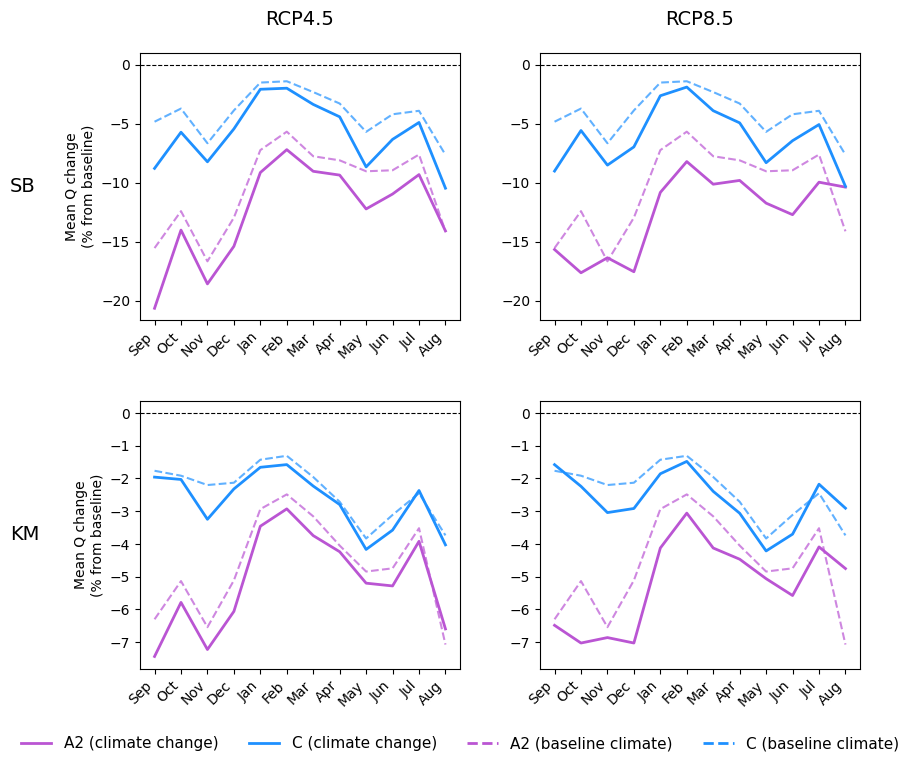

In [17]:
# Relative change plots for SB and KM 
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=False,
    sharey=False
)

plt.subplots_adjust(
    left=0.18,
    right=0.9,
    top=0.92,
    bottom=0.15,
    wspace=0.25,
    hspace=0.30
)

for j, title in enumerate(panels.keys()):
    axes[0, j].set_title(title, fontsize=14, pad=20)


subs = ["SB", "KM"]

for i, sub in enumerate(subs):

    regime_df = globals()[f"{sub}_discharge_regimes"]

    # LULC-only impacts (relative to og baseline)
    a2_baseline = (
        (regime_df["a2"] - regime_df["baseline"])
        / regime_df["baseline"]
    ) * 100

    c_baseline = (
        (regime_df["c"] - regime_df["baseline"])
        / regime_df["baseline"]
    ) * 100

    for j, (panel_name, panel) in enumerate(panels.items()):

        ax = axes[i, j]

        # LULC-CC combined effects (relative to CC baseline)

        a2_climate = (
            (regime_df[panel["a2"]] - regime_df[panel["ref"]])
            / regime_df[panel["ref"]]
        ) * 100

        c_climate = (
            (regime_df[panel["c"]] - regime_df[panel["ref"]])
            / regime_df[panel["ref"]]
        ) * 100

        # A2
        ax.plot(
            hydro_months,
            a2_baseline,
            color="mediumorchid",
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            label="A2"
        )

        ax.plot(
            hydro_months,
            a2_climate,
            color="mediumorchid",
            linestyle="-",
            linewidth=2,
            label=f"A2 + {panel_name}"
        )

        # C
        ax.plot(
            hydro_months,
            c_baseline,
            color="dodgerblue",
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            label="C"
        )

        ax.plot(
            hydro_months,
            c_climate,
            color="dodgerblue",
            linestyle="-",
            linewidth=2,
            label=f"C + {panel_name}"
        )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.8,
            zorder=0
        )

        ax.set_xticks(range(len(hydro_months)))
        ax.set_xticklabels(
            hydro_months,
            rotation=45,
            ha="right"
        )

        ax.grid(False)

        if j == 0:
            ax.set_ylabel(
                "Mean Q change\n(% from baseline)"
            )

name_map = {
    "SB": "SB",
    "KM": "KM"
}

for i, sub in enumerate(subs):

    pos = axes[i, 0].get_position()

    y_center = pos.y0 + pos.height / 2

    fig.text(
        0.05,
        y_center,
        name_map[sub],
        va="center",
        ha="left",
        fontsize=14
    )

for i in range(2):

    row_axes = axes[i, :]

    yvals = np.hstack([
        line.get_ydata()
        for ax in row_axes
        for line in ax.get_lines()
    ])

    ymin = np.nanmin(yvals)
    ymax = np.nanmax(yvals)

    pad = 0.05 * (ymax - ymin)

    for ax in row_axes:
        ax.set_ylim(ymin - pad, ymax + pad)


handles = [
    Line2D([0], [0], color="mediumorchid", lw=2, label="A2 (climate change)"),
    Line2D([0], [0], color="dodgerblue", lw=2, label="C (climate change)"),
    Line2D([0], [0], color="mediumorchid", lw=2, linestyle = "--", label="A2 (baseline climate)"),
    Line2D([0], [0], color="dodgerblue", lw=2, linestyle = "--", label="C (baseline climate)"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=4,
    frameon=False,
    fontsize=11
)

plt.savefig("../Results/Figure_45.png", dpi=400, bbox_inches="tight")
plt.show()

In [36]:
# Extract exact % change values for reference
baseline_45 = (
    (regime_df["2080_45"] - regime_df["baseline"])
    / regime_df["baseline"]
) * 100

baseline_85 = (
    (regime_df["2080_85"] - regime_df["baseline"])
    / regime_df["baseline"]
) * 100

a2_45 = (
    (regime_df["a2_2080_45"] - regime_df["a2"])
    / regime_df["a2"]
) * 100

a2_85 = (
    (regime_df["a2_2080_85"] - regime_df["a2"])
    / regime_df["a2"]
) * 100

c_45 = (
    (regime_df["c_2080_45"] - regime_df["c"])
    / regime_df["c"]
) * 100

c_85 = (
    (regime_df["c_2080_85"] - regime_df["c"])
    / regime_df["c"]
) * 100

In [34]:
print(baseline_45)

Sep   -48.052683
Oct   -30.631809
Nov   -11.325731
Dec     0.529463
Jan     6.463831
Feb    15.244519
Mar    10.053058
Apr     4.803295
May    -1.477190
Jun   -10.906730
Jul   -25.801373
Aug   -40.572834
dtype: float64
